In [ ]:
# !pip install gdown
import gdown
destination = '/content/pdf_json.zip' # store the destination file here
gdown.download('https://drive.google.com/uc?id=1PVA5IR4bAn7RulAeuSgxRBNMtmRGXaUm', destination, quiet=True)
  # this is the original link to dataset
# gdown.download('https://drive.google.com/uc?id=15qcBU4HVSd-Vhm0kaTZt-VsBfbyK0FSn', destination, quiet=True)
  # this is link of the dataset from another gdrive account

'/content/pdf_json.zip'

# Preprocessing


In [ ]:
!unzip -q "/content/pdf_json.zip" # unzipping the file

In [ ]:
import json
def json2text(filename): # json to text converter
    file = open(filename)
    paper_content = json.load(file)
    body_text = ""
    abstract = ""
    title = ""
    # Get the paper_id
    paper_id = paper_content['paper_id']
    # Get the title
    if 'title' in paper_content:
        title = paper_content['title']
    # Get the abstract
    if 'abstract' in paper_content:
        for abs in paper_content['abstract']:
            abstract += abs['text']
    # Get the body text
    if 'body_text' in paper_content:
        for bt in paper_content['body_text']:
            body_text += bt['text']
    return (f'{title} {abstract} {body_text}').lower()

In [ ]:
import os
import multiprocessing as mp
from multiprocessing import Pool

def write_file(filename): # writing the json files into a single text file using multiprocessing
    with open(filename, 'r') as fd:
        return json2text(filename) + " " # we are storing the texts from the json files

def par_write(files):
    '''Read a chunk of files and let the cores of your machine do the job of format conversion in parallel'''
    # Parameter: files - list of files from a folder
    cpu_count = os.cpu_count()
    p = Pool(processes=cpu_count)
    texts_data_list = p.map(write_file, files, chunksize=16)
    p.close()
    p.join()
    data = "\n".join(texts_data_list)
    return data


In [ ]:
folder_path = '/content/pdf_json' # input folder path
files = [os.path.join(folder_path, file) for file in os.listdir(folder_path) if file.endswith('.json')] # storing the list of paths from the input folder
texts_data = par_write(files) # this is storing all the text files from the json files separated by newlines

In [ ]:
with open('/content/texts_data.txt', 'w', encoding='utf-8') as file:
  file.write(texts_data) # saving the texts in a txt file

In [ ]:
import re

input_file_path = "texts_data.txt"
output_file_path = "prep_data.txt" # path to store the preprocessed text file

def preprocess_and_write_line(infile, outfile): # function to do the preprocessing line by line
    while True:
        line = infile.readline()
        if not line:
            break  # end of file reached
        # preprocess the line (case folding and removing numbers)
        preprocessed_line = re.sub(r'[0-9,.":;\'!?(){}[\]<>/\%|@#&]', ' ', line.lower())
        # write the preprocessed line to the output file
        outfile.write(preprocessed_line)

# Open input and output files
with open(input_file_path, "r") as infile, open(output_file_path, "w") as outfile:
    preprocess_and_write_line(infile, outfile) # calling the preprocessor function


saving dataset for testing purpose

In [ ]:
# Define the input and output file paths
input_file_path = 'prep_data.txt'
output_file_path = 'prep_data_test.txt'

# Initialize a list to hold the lines that contain "covid"
lines_to_save = []

numlines = 100
# Open the input file and read the lines
with open(input_file_path, 'r') as input_file:
    for line in input_file:
        if "covid" in line.lower():  # Check if the line contains the word "covid"
            lines_to_save.append(line)
            if len(lines_to_save) >= numlines:  # Stop if we have collected 100 lines
                break

# Open the output file and write the collected lines
with open(output_file_path, 'w') as output_file:
    output_file.writelines(lines_to_save)

print("Some subpart of the dataset is stored in the test dataset")

Some subpart of the dataset is stored in the test dataset


In [ ]:
# freeing up the ram
import gc
files = None
texts_data = None
del files
del texts_data
gc.collect()

3

# (a)


In [ ]:
import numpy as np
import collections
import multiprocessing as mp
import h5py
from tqdm.notebook import tqdm  # Import tqdm

# Parameters
window_size = 4  # Size of the context window

# File path for the corpus
file_path = 'prep_data_test.txt'

# Function to process a line of text into words
def process_line(line):
    return line.strip().split()

# Function to process a chunk of lines for vocabulary and co-occurrence counts
def process_lines(lines):
    local_vocab = collections.Counter()
    local_co_occurrence_counts = collections.defaultdict(lambda: collections.defaultdict(int))

    for line in tqdm(lines, desc="Processing lines", leave=False):  # Add tqdm here
        words = process_line(line)
        local_vocab.update(words)
        for i, word in enumerate(words):
            # Context window
            start = max(0, i - window_size)
            end = min(len(words), i + window_size + 1)
            for j in range(start, end):
                if i != j:
                    local_co_occurrence_counts[word][words[j]] += 1

    return dict(local_vocab), {word: dict(neighbors) for word, neighbors in local_co_occurrence_counts.items()}

# Build vocabulary and co-occurrence counts
def build_co_occurrence_matrix(file_path, window_size, output_file):
    with open(file_path, 'r', encoding='utf-8') as f:
        lines = f.readlines()

    # Use multiprocessing to process the lines in parallel
    num_processes = mp.cpu_count()
    chunk_size = (len(lines) + num_processes - 1) // num_processes  # Ensures all lines are processed
    chunks = [lines[i:i + chunk_size] for i in range(0, len(lines), chunk_size)]

    with mp.Pool(processes=num_processes) as pool:
        results = list(tqdm(pool.imap(process_lines, chunks), total=len(chunks), desc="Processing chunks"))  # Add tqdm here

    # Combine results from all processes
    vocab = collections.Counter()
    co_occurrence_counts = collections.defaultdict(lambda: collections.defaultdict(int))

    for local_vocab, local_co_occurrence_counts in results:
        vocab.update(local_vocab)
        for word, neighbors in local_co_occurrence_counts.items():
            for neighbor, count in neighbors.items():
                co_occurrence_counts[word][neighbor] += count

    # Create HDF5 file for saving the co-occurrence matrix
    total_occurrences = sum(vocab.values())
    vocab_size = len(vocab)
    word_index = {word: idx for idx, word in enumerate(vocab)}

    with h5py.File(output_file, 'w') as f:
        matrix = f.create_dataset('co_occurrence_matrix', shape=(vocab_size, vocab_size), dtype=np.float32)

        # Calculate and save the co-occurrence matrix row-wise
        for word_a, neighbors in tqdm(co_occurrence_counts.items(), desc="Building matrix"):  # Add tqdm here
            if word_a in word_index:
                row_idx = word_index[word_a]
                for word_b, count in neighbors.items():
                    if word_b in word_index:
                        col_idx = word_index[word_b]
                        p_ab = count / total_occurrences

                        p_a = vocab[word_a] / total_occurrences
                        p_b = vocab[word_b] / total_occurrences
                        if p_a > 0 and p_b > 0:
                            matrix[row_idx, col_idx] = p_ab / (p_a * p_b)
                        else:
                            matrix[row_idx, col_idx] = 0

        # Save the vocabulary as a variable-length string array
        vocab_array = np.array(list(vocab.keys()), dtype=h5py.string_dtype(encoding='utf-8'))
        f.create_dataset('vocab', data=vocab_array)

build_co_occurrence_matrix(file_path, window_size, 'co_occurrence_matrix.h5')


Processing chunks:   0%|          | 0/2 [00:00<?, ?it/s]

Building matrix:   0%|          | 0/21380 [00:00<?, ?it/s]

# (b)

In [ ]:
from sklearn.decomposition import TruncatedSVD
import numpy as np
import h5py

# Parameters for SVD
embedding_dim = 50  # Desired dimensionality of the word embeddings
top_n_words = 7000  # Number of most frequent words to select
h5_file_path = 'co_occurrence_matrix.h5'

# Get the top N most frequent words from the HDF5 file
def get_top_n_words(h5_file_path, n):
    with h5py.File(h5_file_path, 'r') as f:
        vocab = f['vocab'][:]
        co_occurrence_matrix = f['co_occurrence_matrix'][:]

    # Compute the frequency of each word by summing up its co-occurrence counts
    word_frequencies = np.sum(co_occurrence_matrix, axis=1)
    top_indices = np.argsort(word_frequencies)[-n:][::-1]
    top_words = [vocab[i].decode('utf-8') for i in top_indices]

    # Manually add the word 'covid' if it's not already included
    if 'covid' not in top_words:
        top_words.append('covid')

    return top_words # returning the top_words

# Compute word embeddings using SVD for the top N most frequent words
def compute_word_embeddings(h5_file_path, top_words, embedding_dim):
    with h5py.File(h5_file_path, 'r') as f:
        vocab = f['vocab'][:]
        co_occurrence_matrix = f['co_occurrence_matrix'][:]

    word_index = {word.decode('utf-8'): i for i, word in enumerate(vocab)}

    # Create the co-occurrence matrix as a numpy array for the top N words
    co_occurrence_array = np.zeros((len(top_words), len(top_words)))
    top_indices = [word_index[word] for word in top_words if word in word_index]

    # Fill the co-occurrence array with relevant values
    for i in range(len(top_indices)):
        for j in range(len(top_indices)):
            co_occurrence_array[i, j] = co_occurrence_matrix[top_indices[i], top_indices[j]]

    # Apply SVD
    svd = TruncatedSVD(n_components=embedding_dim)
    embeddings = svd.fit_transform(co_occurrence_array)

    # Map words to their embeddings
    word_embeddings = {top_words[i]: embeddings[i] for i in range(len(top_indices))}
    return word_embeddings

# Save the word embeddings to a file
def save_word_embeddings(word_embeddings, output_file):
    with open(output_file, 'w') as f:
        for word, embedding in word_embeddings.items():
            embedding_str = ' '.join(f'{value:.6f}' for value in embedding)
            f.write(f'{word}\t{embedding_str}\n')


# Select the top N most frequent words and compute embeddings
top_words = get_top_n_words(h5_file_path, top_n_words)
word_embeddings = compute_word_embeddings(h5_file_path, top_words, embedding_dim)

# Save the computed word embeddings
save_word_embeddings(word_embeddings, 'word_embeddings.txt')


In [ ]:
print(word_embeddings)

{'pelagium': array([ 4.98072540e+05, -2.70529010e+01,  6.06287156e+05, -1.67274846e+05,
       -7.87228948e+04,  1.44190057e+01, -1.03655462e+02,  9.24242222e+04,
       -1.76961237e+02, -1.72045737e+02,  4.31170106e+04, -6.83433178e+02,
       -2.94098087e+02, -8.54449076e+02,  5.34254864e+02, -9.59261021e+02,
        1.66506204e+01,  7.28045627e+02,  7.88199127e+02,  4.66389670e+02,
        2.16630533e+03,  2.14341662e+04, -6.33385305e+03,  3.30161094e+03,
        6.39272457e+03,  2.42438096e+03,  1.09581597e+03, -4.27276220e+02,
        7.46988656e+02, -4.31739994e+03, -1.29328562e+02, -1.40349579e+04,
        8.07947880e+03,  4.47904891e+03,  3.18522396e+04,  5.18263201e+03,
       -4.33639437e+04, -1.35374422e+04,  1.33027299e+04, -1.72212934e+03,
        1.65956354e+03,  1.02420662e+04,  3.74549935e+02, -7.30241480e+03,
        1.86493428e+04, -5.52327526e+04,  1.87179046e+04,  1.01266185e+04,
        2.06781699e+02, -2.19859438e+04]), 'amammou': array([ 3.25488187e+00,  8.205403

# (c)

In [ ]:
import h5py

# Function to get vocabulary size, co-occurrence matrix size, and order from the HDF5 file
def get_matrix_sizes(h5_file_path):
    with h5py.File(h5_file_path, 'r') as f:
        vocab = f['vocab'][:]  # Load vocabulary
        vocab_size = len(vocab)  # Vocabulary size

        # Get the shape of the co-occurrence matrix without loading it entirely
        co_occurrence_matrix_shape = f['co_occurrence_matrix'].shape
        matrix_rows, matrix_cols = co_occurrence_matrix_shape
        matrix_size = matrix_rows * matrix_cols  # Total number of elements

    print(f'Vocabulary size: {vocab_size}')
    print(f'Co-occurrence matrix order: {matrix_rows} x {matrix_cols}')
    print(f'Co-occurrence matrix size: {matrix_size}')

get_matrix_sizes('co_occurrence_matrix.h5')


Vocabulary size: 21380
Co-occurrence matrix order: 21380 x 21380
Co-occurrence matrix size: 457104400


# (d)

----------------------------------------

In [ ]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from tqdm.notebook import tqdm  # Use notebook version of tqdm for Colab
import spacy
from collections import Counter

# Function to read word embeddings from the file
def load_word_embeddings(file_path):
    word_embeddings = {}
    with open(file_path, 'r') as f:
        for line in f:
            parts = line.strip().split()
            word = parts[0]  # The first item is the word
            embedding = np.array([float(x) for x in parts[1:]])  # The rest are the embedding values
            word_embeddings[word] = embedding
    return word_embeddings

# Function to compute cosine similarity between word vectors
def compute_cosine_similarity(word, word_embeddings, top_n=5):
    if word not in word_embeddings:
        return []

    # Extract the vector for the given word
    word_vector = word_embeddings[word].reshape(1, -1)

    # Compute cosine similarities with all other words in the vocabulary
    similarities = {}
    for other_word, other_vector in tqdm(word_embeddings.items(), desc=f"Calculating similarities for '{word}'", leave=False):
        if word != other_word:
            similarity = cosine_similarity(word_vector, other_vector.reshape(1, -1))[0][0]
            similarities[other_word] = similarity

    # Sort the words by similarity and return the top_n most similar words
    similar_words = sorted(similarities.items(), key=lambda item: item[1], reverse=True)[:top_n]
    return similar_words

# Function to extract nouns and verbs from the corpus
def extract_nouns_and_verbs(file_path):
    nouns = []
    verbs = []
    with open(file_path, 'r') as f:
        for line in f:
            # Process the line with SpaCy
            doc = nlp(line.strip())
            for token in doc:
                if token.pos_ == "NOUN":
                    nouns.append(token.text)
                elif token.pos_ == "VERB":
                    verbs.append(token.text)
    return nouns, verbs

# Load the SpaCy model
nlp = spacy.load("en_core_web_sm")

# Load word embeddings from the file
word_embeddings = load_word_embeddings('word_embeddings.txt')

# Extract nouns and verbs from the corpus
nouns, verbs = extract_nouns_and_verbs('prep_data_test.txt')

# Generate five similar nouns and verbs for the word 'covid' and display the cosine distances
chosen_word = 'covid'

print(f"Top 5 similar nouns to '{chosen_word}':")
similar_nouns = compute_cosine_similarity(chosen_word, word_embeddings, top_n=5)
noun_list = [word for word, _ in similar_nouns if word in nouns]

# If less than 5 similar nouns, add the most frequent nouns
if len(noun_list) < 5: # in case enough similar nouns are not found it takes nouns from the word embedding and the input text
    most_common_nouns = Counter(nouns).most_common(5 - len(noun_list))
    noun_list.extend([word for word, _ in most_common_nouns])

# Limit to the first 5 nouns
noun_list = noun_list[:5]

for similar_word in noun_list:
    similarity = next((similarity for word, similarity in similar_nouns if word == similar_word), None)
    if similarity is not None:
        print(f"\t{similar_word}: {similarity:.4f}")
    else:
        print(f"\t{similar_word}")

print(f"Top 5 similar verbs to '{chosen_word}':")
similar_verbs = compute_cosine_similarity(chosen_word, word_embeddings, top_n=5)
verb_list = [word for word, _ in similar_verbs if word in verbs]

# If less than 5 similar verbs, add the most frequent verbs
if len(verb_list) < 5: # in case enough similar nouns are not found it takes verbs from the word embedding and the input text
    most_common_verbs = Counter(verbs).most_common(5 - len(verb_list))
    verb_list.extend([word for word, _ in most_common_verbs])

# Limit to the first 5 verbs
verb_list = verb_list[:5]

for similar_word in verb_list:
    similarity = next((similarity for word, similarity in similar_verbs if word == similar_word), None)
    if similarity is not None:
        print(f"\t{similar_word}: {similarity:.4f}")
    else:
        print(f"\t{similar_word}")


Top 5 similar nouns to 'covid':


Calculating similarities for 'covid':   0%|          | 0/7001 [00:00<?, ?it/s]

	elle: 0.9828
	patients
	data
	sars
	disease
Top 5 similar verbs to 'covid':


Calculating similarities for 'covid':   0%|          | 0/7001 [00:00<?, ?it/s]

	reported
	using
	used
	based
	including


# (e)

In [ ]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

# Function to compute cosine similarity between word vectors
def compute_cosine_similarity(word, word_embeddings, vocab, top_n=5):
    if word not in word_embeddings:
        return []

    # Extract the vector for the given word
    word_vector = word_embeddings[word].reshape(1, -1)

    # Compute cosine similarities with all other words in the vocabulary
    similarities = {}
    for other_word, other_vector in word_embeddings.items():
        if word != other_word:
            similarity = cosine_similarity(word_vector, other_vector.reshape(1, -1))[0][0]
            similarities[other_word] = similarity

    # Sort the words by similarity and return the top_n most similar words
    similar_words = sorted(similarities.items(), key=lambda item: item[1], reverse=True)[:top_n]
    return similar_words # return the similar words

word_embeddings = load_word_embeddings('word_embeddings.txt')
chosen_words = ['covid'] + top_words[:4] # chosen words top_words in the list

lst = []
# Generate five similar words for each chosen word and display the cosine distances
for word in chosen_words:
    similar_words = compute_cosine_similarity(word, word_embeddings, chosen_words, top_n=5)
    print(f"Top 5 similar words for '{word}':")
    lst += [similar_words]
    for similar_word, similarity in similar_words:
        print(f"\t{similar_word}: {similarity:.4f}")


Top 5 similar words for 'covid':
	pre-warned: 0.9837
	alcool: 0.9833
	centrée: 0.9833
	elle: 0.9828
	qu: 0.9824
Top 5 similar words for 'pelagium':
	papam: 0.9965
	primumque: 0.9897
	virum: 0.9584
	remanerent: 0.9471
	pauci: 0.9122
Top 5 similar words for 'amammou':
	jaweher: 0.9996
	badii: 0.9979
	masmoudi: 0.9957
	neffeti: 0.9945
	aida: 0.9896
Top 5 similar words for 'badii':
	neffeti: 0.9992
	amammou: 0.9979
	aida: 0.9968
	jaweher: 0.9957
	boussaker: 0.9933
Top 5 similar words for 'serpentium':
	multa: 0.9825
	draco: 0.9657
	cum: 0.9626
	etiam: 0.9327
	fluminis: 0.8755


# (f)

In [ ]:
lst = [[word for word, _ in sublist] for sublist in lst]

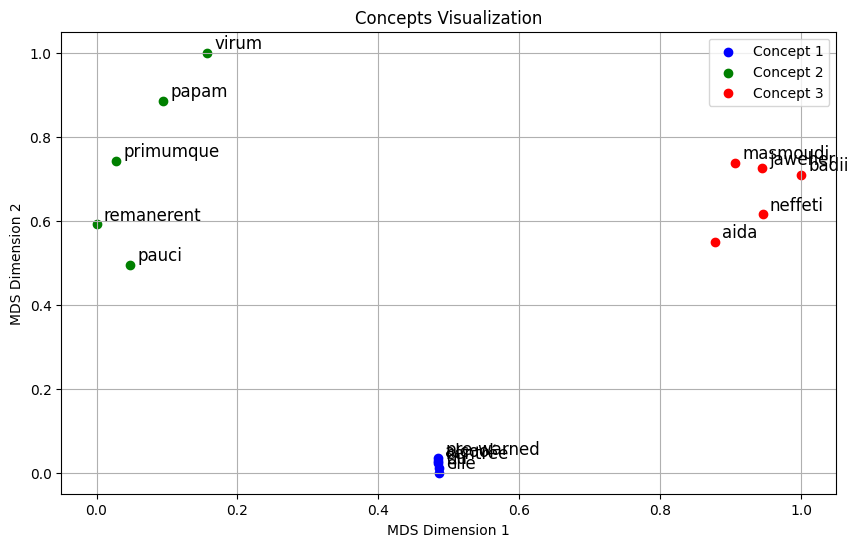

In [ ]:
import matplotlib.pyplot as plt
from sklearn.manifold import MDS
import numpy as np
from sklearn.preprocessing import MinMaxScaler

concept1_words = lst[0]
concept2_words = lst[1]
concept3_words = lst[2]

# Combine all words
all_words = concept1_words + concept2_words + concept3_words

# Filter words that are present in the embeddings
valid_words = [word for word in all_words if word in word_embeddings]
valid_embeddings = [word_embeddings[word] for word in valid_words]

# Use Multi-Dimensional Scaling (MDS) to reduce the dimensionality to 2D for visualization
if valid_embeddings:
    mds = MDS(n_components=2, random_state=42, normalized_stress='auto')  # Added normalized_stress='auto'
    reduced_embeddings = mds.fit_transform(valid_embeddings)

    # Normalize the embeddings for better plotting
    scaler = MinMaxScaler()
    normalized_embeddings = scaler.fit_transform(reduced_embeddings)

# Function to plot all concepts on the same graph
def plot_concepts_together(reduced_embeddings, concept1_valid, concept2_valid, concept3_valid):
    plt.figure(figsize=(10, 6))

    # Plot Concept 1
    if len(concept1_valid) > 0:
        plt.scatter(reduced_embeddings[:len(concept1_valid), 0], reduced_embeddings[:len(concept1_valid), 1], color='blue', label='Concept 1')
        for i, word in enumerate(concept1_valid):
            plt.text(reduced_embeddings[i, 0] + 0.01, reduced_embeddings[i, 1] + 0.01, word, fontsize=12)

    # Plot Concept 2
    start_idx = len(concept1_valid)
    if len(concept2_valid) > 0:
        plt.scatter(reduced_embeddings[start_idx:start_idx + len(concept2_valid), 0], reduced_embeddings[start_idx:start_idx + len(concept2_valid), 1], color='green', label='Concept 2')
        for i, word in enumerate(concept2_valid):
            plt.text(reduced_embeddings[start_idx + i, 0] + 0.01, reduced_embeddings[start_idx + i, 1] + 0.01, word, fontsize=12)

    # Plot Concept 3
    start_idx += len(concept2_valid)
    if len(concept3_valid) > 0:
        plt.scatter(reduced_embeddings[start_idx:start_idx + len(concept3_valid), 0], reduced_embeddings[start_idx:start_idx + len(concept3_valid), 1], color='red', label='Concept 3')
        for i, word in enumerate(concept3_valid):
            plt.text(reduced_embeddings[start_idx + i, 0] + 0.01, reduced_embeddings[start_idx + i, 1] + 0.01, word, fontsize=12)

    # Plotting functions
    plt.title('Concepts Visualization')
    plt.xlabel('MDS Dimension 1')
    plt.ylabel('MDS Dimension 2')
    plt.grid(True)
    plt.xlim(reduced_embeddings[:, 0].min() - 0.05, reduced_embeddings[:, 0].max() + 0.05)
    plt.ylim(reduced_embeddings[:, 1].min() - 0.05, reduced_embeddings[:, 1].max() + 0.05)
    plt.legend(loc='upper right')
    plt.show()

# Adjust the plotting to reflect valid words only
concept1_valid = [word for word in concept1_words if word in word_embeddings]
concept2_valid = [word for word in concept2_words if word in word_embeddings]
concept3_valid = [word for word in concept3_words if word in word_embeddings]

# Plot all concepts together
plot_concepts_together(normalized_embeddings, concept1_valid, concept2_valid, concept3_valid)


In [ ]:
# Printing the concepts
print("Concept1: ", chosen_words[0]," :", lst[0])
print("Concept2: ", chosen_words[1]," :", lst[1])
print("Concept3: ", chosen_words[2]," :", lst[2])

Concept1:  covid  : ['pre-warned', 'alcool', 'centrée', 'elle', 'qu']
Concept2:  pelagium  : ['papam', 'primumque', 'virum', 'remanerent', 'pauci']
Concept3:  amammou  : ['jaweher', 'badii', 'masmoudi', 'neffeti', 'aida']
